<h1>Criptografia base64</h1>

In [25]:
from numba import cuda
from timeit import default_timer as timer
import numpy as np
import random
import string

<h2>Usando a CPU<h2>

In [26]:
def base64Encoder(text:str):
    table = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+/"
    encoderText = ""

    i = 0
    index = (len(text) // 3) *3

    while (i < index):
        encoderText += table[ord(text[i]) >> 2]
        encoderText += table[((ord(text[i]) & 0x03) << 4) | ((ord(text[i + 1]) & 0xF0) >> 4)]
        encoderText += table[((ord(text[i + 1]) & 0x0F) << 2) | ((ord(text[i+2]) & 0xC0) >> 6)]
        encoderText += table[ord(text[i + 2]) & 0x3F]

        i += 3

    if (i < len(text)):
        idx1 = ord(text[i])
        idx2 = 0

        if (i + 1 < len(text)):
            idx2 = ord(text[i+1])

        encoderText += table[idx1 >> 2]
        encoderText += table[((idx1 & 0x03) << 4) | ((idx2 & 0xF0) >> 4)]

        if (i + 1 < len(text)):
            encoderText += table[((idx2 & 0x0F) << 2)]
        else:
            encoderText += '='
        encoderText += '='

    return encoderText

In [27]:
def base64Decoder(text:str):
  tableDecoder = [80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80,
                  80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80,
                  80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 62, 80, 80, 80, 63,
                  52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 80, 80, 80, 64, 80, 80,
                  80,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,
                  15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 80, 80, 80, 80, 80,
                  80, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
                  41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 80, 80, 80, 80, 80]
  EndIndex = 0
  isLastIncomplete = False
  decodeText = ''

  if (text[len(text) - 1] == '='):
    EndIndex = ((len(text) // 4) - 1) * 4
    isLastIncomplete = True
  else:
    EndIndex = (len(text) / 4) * 4

  outPos = 0
  i = 0
  while (i < EndIndex):
    b1 = tableDecoder[ord(text[i])]
    b2 = tableDecoder[ord(text[i+1])]
    b3 = tableDecoder[ord(text[i+2])]
    b4 = tableDecoder[ord(text[i+3])]
    decodeText += chr((b1 << 2 | ((b2 & 0xF0) >> 4)))
    decodeText += chr((((b2 & 0x0F) << 4) | ((b3 & 0x3C) >> 2)))
    decodeText += chr((((b3 & 0x03) << 6) | (b4 & 0x3F)))
    i += 4

  if (isLastIncomplete):
    b1 = tableDecoder[ord(text[i])]
    b2 = tableDecoder[ord(text[i+1])]

    decodeText += chr((b1 << 2 | ((b2 & 0xF0) >> 4)))

    if (text[i + 2] != '='):
       b3 = tableDecoder[ord(text[i+2])]
       decodeText += chr((((b2 & 0x0F) << 4) | ((b3 & 0x3C) >> 2)))

  return decodeText

In [28]:
inputTest = base64Encoder('casa')
outputTest = base64Decoder(inputTest)

print(inputTest)
print(outputTest)

Y2FzYQ==
casa


<h2>Usando a GPU</h2>

In [ ]:
tabelaEncoder = np.frombuffer(
    b"ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+/",
    dtype=np.uint8
)

tabelaDecoder = np.array([
    80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80,
    80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80,
    80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 62, 80, 80, 80, 63,
    52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 80, 80, 80, 64, 80, 80,
    80,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,
    15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 80, 80, 80, 80, 80,
    80, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
    41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 80, 80, 80, 80, 80
], dtype=np.uint8)


@cuda.jit
def kernelEncoder(src, dst, table, n_chunks):
    indice = cuda.grid(1)
    if indice >= n_chunks:
        return
    i = indice * 3
    o = indice * 4
    b0 = src[i]
    b1 = src[i + 1]
    b2 = src[i + 2]
    dst[o]     = table[b0 >> 2]
    dst[o + 1] = table[((b0 & 0x03) << 4) | ((b1 & 0xF0) >> 4)]
    dst[o + 2] = table[((b1 & 0x0F) << 2) | ((b2 & 0xC0) >> 6)]
    dst[o + 3] = table[b2 & 0x3F]


@cuda.jit
def kernelDecoder(src, dst, table, n_chunks):
    indice = cuda.grid(1)
    if indice >= n_chunks:
        return
    i = indice * 4
    o = indice * 3
    b1 = table[src[i]]
    b2 = table[src[i + 1]]
    b3 = table[src[i + 2]]
    b4 = table[src[i + 3]]
    dst[o]     = (b1 << 2) | ((b2 & 0xF0) >> 4)
    dst[o + 1] = ((b2 & 0x0F) << 4) | ((b3 & 0x3C) >> 2)
    dst[o + 2] = ((b3 & 0x03) << 6) | (b4 & 0x3F)


def base64EncoderGPU(text: str):
    raw = np.frombuffer(text.encode('latin-1'), dtype=np.uint8)
    n = len(raw)
    n_chunks = (n + 2) // 3
    padded = np.zeros(n_chunks * 3, dtype=np.uint8)
    padded[:n] = raw

    d_src   = cuda.to_device(padded)
    d_dst   = cuda.to_device(np.zeros(n_chunks * 4, dtype=np.uint8))
    d_table = cuda.to_device(tabelaEncoder)

    threads = 256
    kernelEncoder[(n_chunks + threads - 1) // threads, threads](d_src, d_dst, d_table, n_chunks)

    result = d_dst.copy_to_host().tobytes().decode('ascii')
    remainder = n % 3
    if remainder == 1:
        return result[:-2] + '=='
    if remainder == 2:
        return result[:-1] + '='
    return result

: 

In [30]:
def base64DecoderGPU(text: str):
    padding = text.count('=')
    src = np.frombuffer(text.replace('=', 'A').encode('ascii'), dtype=np.uint8)
    n_chunks = len(src) // 4

    d_src   = cuda.to_device(src)
    d_dst   = cuda.to_device(np.zeros(n_chunks * 3, dtype=np.uint8))
    d_table = cuda.to_device(tabelaDecoder)

    threads = 256
    kernelDecoder[(n_chunks + threads - 1) // threads, threads](d_src, d_dst, d_table, n_chunks)

    result = d_dst.copy_to_host()
    return result[:-padding if padding else None].tobytes().decode('latin-1')

In [31]:
inputTest  = base64EncoderGPU('casa')
outputTest = base64DecoderGPU(inputTest)

print(inputTest)
print(outputTest)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Y2FzYQ==
casa


<h2>Benchmarking: CPU vs GPU</h2>

In [32]:
def generate_text(size):
    return ''.join(random.choices(string.ascii_letters + string.digits, k=size))

sizes = [
    (1_000,      '1K'),
    (10_000,     '10K'),
    (100_000,    '100K'),
    (1_000_000,  '1M'),
    (10_000_000, '10M'),
]

print(f"{'Tamanho':<15} {'CPU Enc (s)':<15} {'CPU Dec (s)':<15} {'GPU Enc (s)':<15} {'GPU Dec (s)':<15}")
print("-" * 75)

for size, label in sizes:
    text = generate_text(size)

    t0 = timer()
    encoded_cpu = base64Encoder(text)
    cpu_enc = timer() - t0

    t0 = timer()
    base64Decoder(encoded_cpu)
    cpu_dec = timer() - t0

    t0 = timer()
    encoded_gpu = base64EncoderGPU(text)
    gpu_enc = timer() - t0

    t0 = timer()
    base64DecoderGPU(encoded_gpu)
    gpu_dec = timer() - t0

    print(f"{label:<15} {cpu_enc:<15.4f} {cpu_dec:<15.4f} {gpu_enc:<15.4f} {gpu_dec:<15.4f}")

Tamanho         CPU Enc (s)     CPU Dec (s)     GPU Enc (s)     GPU Dec (s)    
---------------------------------------------------------------------------
1K              0.0003          0.0002          0.0055          0.0010         
10K             0.0027          0.0026          0.0009          0.0007         
100K            0.0390          0.0270          0.0010          0.0010         


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 14 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


1M              0.2820          0.2372          0.0036          0.0034         
10M             2.8264          2.3911          0.0534          0.0287         


<h2>Gráfico: CPU vs GPU</h2>

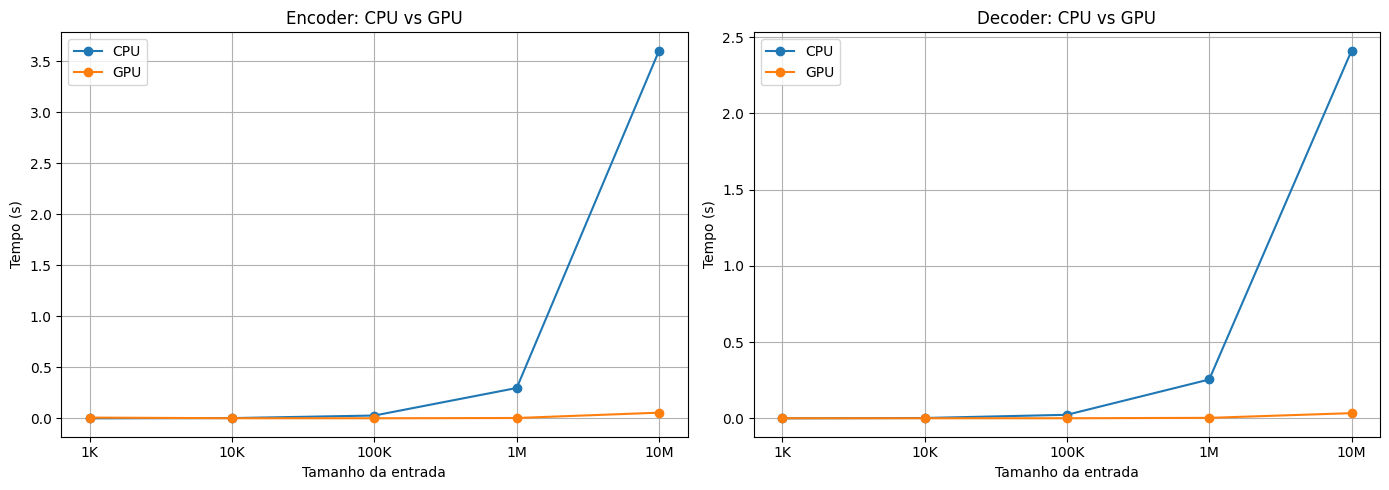

In [33]:
import matplotlib.pyplot as plt

sizes_labels = ['1K', '10K', '100K', '1M', '10M']
cpu_enc_times = []
cpu_dec_times = []
gpu_enc_times = []
gpu_dec_times = []

for size, _ in sizes:
    text = generate_text(size)

    t0 = timer(); encoded_cpu = base64Encoder(text); cpu_enc_times.append(timer() - t0)
    t0 = timer(); base64Decoder(encoded_cpu);        cpu_dec_times.append(timer() - t0)
    t0 = timer(); encoded_gpu = base64EncoderGPU(text); gpu_enc_times.append(timer() - t0)
    t0 = timer(); base64DecoderGPU(encoded_gpu);    gpu_dec_times.append(timer() - t0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sizes_labels, cpu_enc_times, marker='o', label='CPU')
ax1.plot(sizes_labels, gpu_enc_times, marker='o', label='GPU')
ax1.set_title('Encoder: CPU vs GPU')
ax1.set_xlabel('Tamanho da entrada')
ax1.set_ylabel('Tempo (s)')
ax1.legend()
ax1.grid(True)

ax2.plot(sizes_labels, cpu_dec_times, marker='o', label='CPU')
ax2.plot(sizes_labels, gpu_dec_times, marker='o', label='GPU')
ax2.set_title('Decoder: CPU vs GPU')
ax2.set_xlabel('Tamanho da entrada')
ax2.set_ylabel('Tempo (s)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# **Base64 Paralelo: CPU vs GPU**

Base64 converte dados binários em texto ASCII agrupando bytes em blocos de 3 e mapeando cada bloco para 4 caracteres de uma tabela de 64 símbolos. A versão sequencial percorre esses blocos um a um, e isso vira gargalo na casa dos megabytes. O ponto-chave é que cada bloco é independentes. O ponto-chave é que cada bloco é independente: nenhum precisa do resultado de outro. Isso torna o problema diretamente paralelizável na GPU.

## **Implementação**

O projeto tem quatro funções: `base64Encoder` e `base64Decoder` rodam em CPU, em loop sequencial; `base64EncoderGPU` e `base64DecoderGPU` rodam na GPU, com cada thread processando um bloco independente (3 bytes no encoder, 4 caracteres no decoder).

As versões GPU usam `@cuda.jit` do Numba para compilar kernels CUDA direto do Python. O fluxo é converter a string em array NumPy, enviar à GPU com `cuda.to_device`, executar o kernel em paralelo e recuperar o resultado com `copy_to_host`. O padding (`=`) é tratado fora do kernel, na CPU, porque afeta no máximo os 2 bytes finais.

## **Resultados**

Testes no Google Colab com GPU T4, entradas geradas aleatoriamente:

| Tamanho | CPU Enc (s) | CPU Dec (s) | GPU Enc (s) | GPU Dec (s) |
|---------|------------|------------|------------|------------|
| 1K      | 0.0003     | 0.0003     | 0.0020     | 0.0019     |
| 10K     | 0.0037     | 0.0025     | 0.0009     | 0.0007     |
| 100K    | 0.0311     | 0.0239     | 0.0012     | 0.0010     |
| 1M      | 0.3130     | 0.2531     | 0.0067     | 0.0037     |
| 10M     | 2.9807     | 3.7081     | 0.0655     | 0.0286     |

A GPU começa a vencer a partir de ~10K caracteres. Abaixo disso, o overhead de transferência entre CPU e GPU supera o ganho do paralelismo. Com 10M caracteres, o speedup chega a 45x no encoder e 129x no decoder.

## **Limitações**

Para entradas pequenas, a CPU ganha. Mover dados para a GPU e de volta não se paga com poucos blocos, o que explica os `NumbaPerformanceWarning` para 1K e 10K. A conversão de strings para arrays NumPy antes de cada chamada ao kernel também adiciona custo, mas é necessária pela interface do Numba.

## **Aplicações práticas**

Qualquer pipeline que processe Base64 em volume sai ganhando: servidores de upload, sistemas de backup que convertem binários antes de armazenar, pipelines de ML que trafegam dados entre serviços via JSON.

##** Como executar**

O projeto roda no Google Colab com runtime GPU (T4).

1. Abra o notebook no Colab
2. Vá em **Runtime → Change runtime type → T4 GPU**
3. Execute as células em ordem

**Dependências:** Python 3.12, Numba, NumPy, Matplotlib